In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.io

import skimage as ski
from skimage.filters import gaussian
from skimage import measure

# dataset
image_sequence = ski.data.nickel_solidification()

# crop
y0, y1, x0, x1 = 0, 180, 100, 330
image_sequence = image_sequence[:, y0:y1, x0:x1]

print(f'shape: {image_sequence.shape}')

shape: (11, 180, 230)


In [ ]:
fig = px.imshow(
    image_sequence,
    animation_frame=0,
    binary_string=True,
    labels={'animation_frame': 'time point'},
)
plotly.io.show(fig)

In [ ]:
smoothed = ski.filters.gaussian(image_sequence)
image_deltas = smoothed[1:, :, :] - smoothed[:-1, :, :]

fig = px.imshow(
    image_deltas,
    animation_frame=0,
    binary_string=True,
    labels={'animation_frame': 'time point'},
)
plotly.io.show(fig)

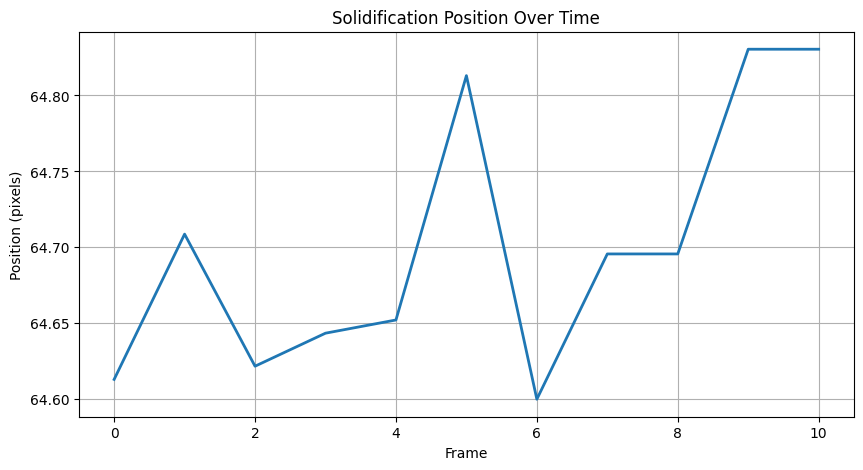

In [ ]:
interface_positions = []

for i, frame in enumerate(image_sequence):

    # suaviza ruído
    smooth = gaussian(frame, sigma=2)

    # gradiente vertical
    grad = np.abs(np.gradient(smooth, axis=0))

    # posição da maior mudança por coluna
    interface_y = np.argmax(grad, axis=0)

    # média da posição da interface
    mean_interface = np.mean(interface_y)

    interface_positions.append(mean_interface)



plt.figure(figsize=(10, 5))

plt.plot(interface_positions, linewidth=2)

plt.title("Solidification Position Over Time")
plt.xlabel("Frame")
plt.ylabel("Position (pixels)")

plt.grid(True)

plt.show()

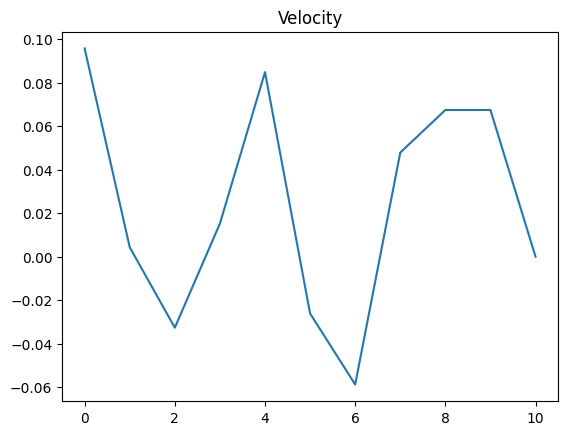

In [ ]:
velocity = np.gradient(interface_positions)

plt.plot(velocity)
plt.title("Velocity")
plt.show()

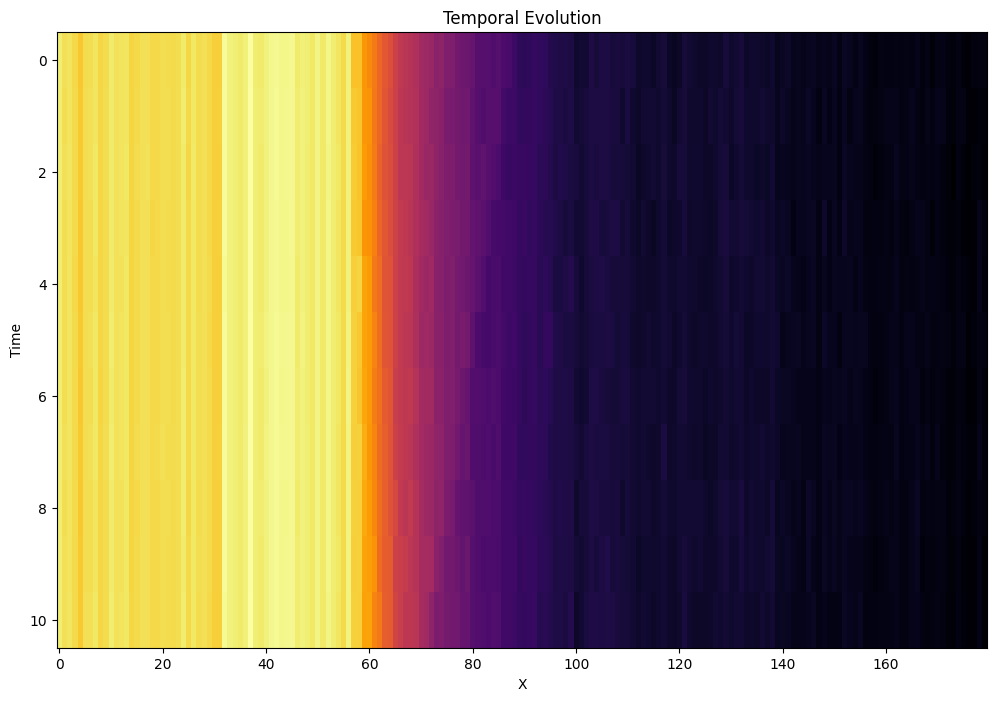

In [ ]:
plt.figure(figsize=(12, 8))

plt.imshow(
    image_sequence[:, :, 100],
    aspect='auto',
    cmap='inferno'
)

plt.title("Temporal Evolution")
plt.xlabel("X")
plt.ylabel("Time")

plt.show()

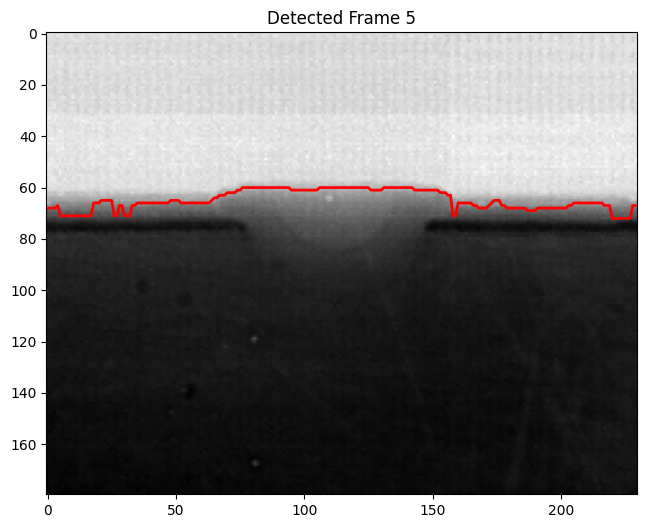

In [ ]:
frame_id = 5

frame = image_sequence[frame_id]

smooth = gaussian(frame, sigma=2)

grad = np.abs(np.gradient(smooth, axis=0))

interface_y = np.argmax(grad, axis=0)

plt.figure(figsize=(8, 6))

plt.imshow(frame, cmap="gray")

plt.plot(
    np.arange(len(interface_y)),
    interface_y,
    color="red",
    linewidth=2
)

plt.title(f"Detected Frame {frame_id}")

plt.show()

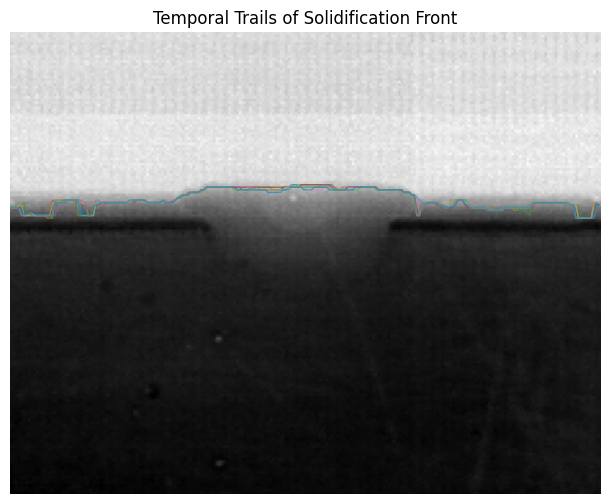

In [ ]:
plt.figure(figsize=(8, 6))
plt.imshow(image_sequence[-1], cmap="gray")

for i, frame in enumerate(image_sequence):
    smooth = gaussian(frame, sigma=2)
    grad = np.abs(np.gradient(smooth, axis=0))
    interface_y = np.argmax(grad, axis=0)

    plt.plot(
        np.arange(len(interface_y)),
        interface_y,
        linewidth=1,
        alpha=0.5,
        label=f"Frame {i}"
    )

plt.title("Temporal Trails of Solidification Front")
plt.axis("off")
plt.show()

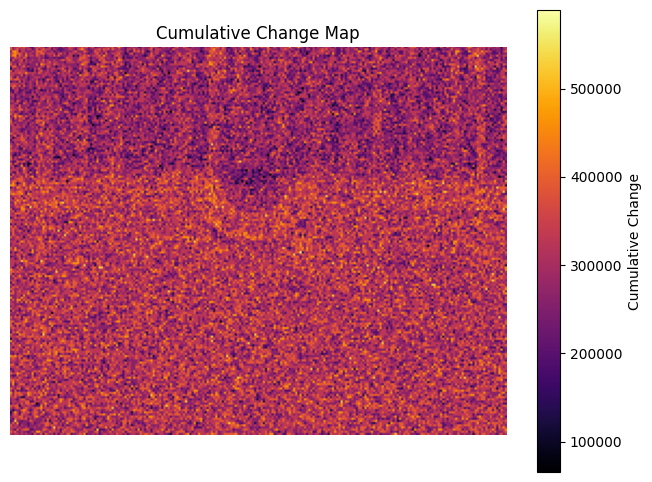

In [ ]:
change_map = np.zeros_like(image_sequence[0], dtype=float)

for i in range(len(image_sequence) - 1):
    change_map += np.abs(image_sequence[i + 1] - image_sequence[i])

plt.figure(figsize=(8, 6))
plt.imshow(change_map, cmap="inferno")
plt.title("Cumulative Change Map")
plt.axis("off")
plt.colorbar(label="Cumulative Change")
plt.show()

In [ ]:
features = []

for i, frame in enumerate(image_sequence):
    smooth = gaussian(frame, sigma=2)
    grad = np.abs(np.gradient(smooth, axis=0))
    interface_y = np.argmax(grad, axis=0)

    gy, gx = np.gradient(smooth)
    orientation = np.arctan2(gy, gx)

    features.append({
        "frame": i,
        "mean_interface_position": np.mean(interface_y),
        "interface_roughness": np.std(interface_y),
        "transition_thickness": np.mean(grad > np.percentile(grad, 95)),
        "structural_density": np.mean(grad > np.percentile(grad, 90)),
        "mean_orientation": np.mean(orientation),
        "orientation_std": np.std(orientation)
    })

df_features = pd.DataFrame(features)
df_features

# df_features.to_csv("nickel_solidification_features.csv", index=False)

,frame,mean_interface_position,interface_roughness,transition_thickness,structural_density,mean_orientation,orientation_std
0,0,64.613043,3.865433,0.05,0.1,-0.665722,1.546131
1,1,64.708696,3.859197,0.05,0.1,-0.677746,1.544137
2,2,64.621739,3.878643,0.05,0.1,-0.675242,1.546703
3,3,64.643478,3.819154,0.05,0.1,-0.683518,1.537687
4,4,64.652174,3.738271,0.05,0.1,-0.697901,1.532099
5,5,64.813043,3.812429,0.05,0.1,-0.682859,1.544045
6,6,64.600000,3.536886,0.05,0.1,-0.686222,1.537623
7,7,64.695652,3.567179,0.05,0.1,-0.674909,1.543531
8,8,64.695652,3.537806,0.05,0.1,-0.669776,1.543181
9,9,64.830435,3.635804,0.05,0.1,-0.676421,1.546368
